In [9]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from collections import Counter
from itertools import combinations
from typing import Tuple, List

from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

# Set random seed for reproducibility
np.random.seed(42)

# Fashion-MNIST class labels
LABELS = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def plot_confusion(cm, labels, title="Confusion Matrix"):
    """Plot confusion matrix with proper formatting"""
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation="nearest", cmap='Blues')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    
    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                   fontsize=10, color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    # Add colorbar
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [10]:
# Load Fashion-MNIST via Keras
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
print("Full train:", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)

# 80/20 stratified split for train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

# Save shapes for report
shapes_info = {
    "train_shape": X_train.shape, "val_shape": X_val.shape, "test_shape": X_test.shape
}
shapes_info

Full train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Train: (48000, 28, 28) (48000,)
Val: (12000, 28, 28) (12000,)


{'train_shape': (48000, 28, 28),
 'val_shape': (12000, 28, 28),
 'test_shape': (10000, 28, 28)}

/var/folders/h7/_rjcfbvn6n382t_y18r9wd4h0000gn/T/ipykernel_10346/3932111529.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABELS, rotation=45, ha="right")


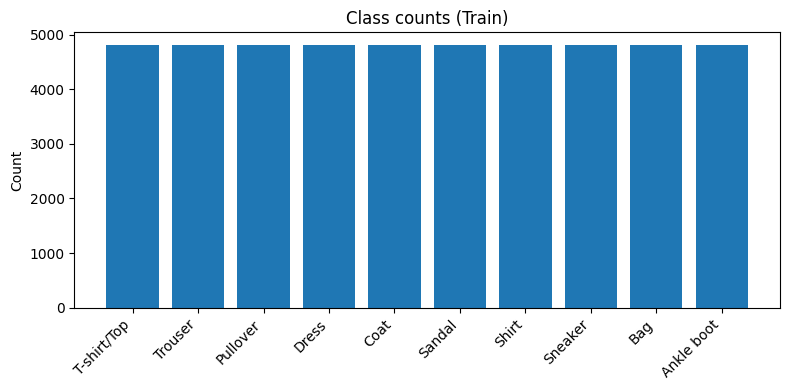

Global mean: 72.994 Global std: 90.059
Per-class mean pixel intensity:
  T-shirt/Top: 82.850
  Trouser: 56.987
  Pullover: 96.491
  Dress: 66.122
  Coat: 98.100
  Sandal: 34.800
  Shirt: 84.826
  Sneaker: 42.838
  Bag: 90.169
  Ankle boot: 76.761


In [12]:
# Class distribution on training set
counts = Counter(y_train)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar([LABELS[i] for i in range(10)], [counts[i] for i in range(10)])
ax.set_title("Class counts (Train)")
ax.set_ylabel("Count")
ax.set_xticklabels(LABELS, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Global pixel mean/std and per-class mean pixel intensity
global_mean = X_train.astype(np.float32).mean()
global_std  = X_train.astype(np.float32).std()

per_class_means = {}
for c in range(10):
    per_class_means[LABELS[c]] = X_train[y_train==c].astype(np.float32).mean()

print("Global mean:", round(float(global_mean), 3), "Global std:", round(float(global_std), 3))
print("Per-class mean pixel intensity:")
for k,v in per_class_means.items():
    print(f"  {k}: {v:.3f}")

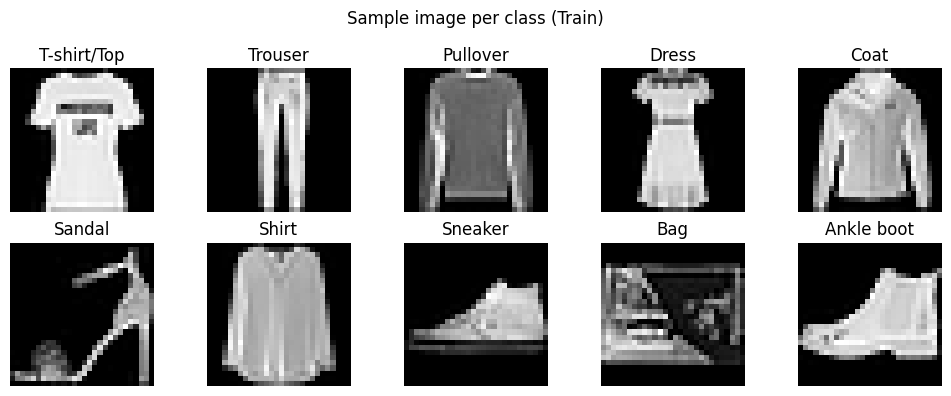

In [13]:
# Visualization: one sample image per class (from train)
fig, axes = plt.subplots(2,5, figsize=(10,4))
axes = axes.ravel()
for c in range(10):
    idx = np.where(y_train==c)[0][0]
    axes[c].imshow(X_train[idx], cmap="gray")
    axes[c].set_title(LABELS[c])
    axes[c].axis("off")
plt.suptitle("Sample image per class (Train)")
plt.tight_layout()
plt.show()

In [14]:
# Flatten to 2D
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32)
X_val_flat   = X_val.reshape(len(X_val), -1).astype(np.float32)
X_test_flat  = X_test.reshape(len(X_test), -1).astype(np.float32)

# Before scaling stats
m_before = X_train_flat.mean(); s_before = X_train_flat.std()

# Standardize
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_flat)
X_val_std   = scaler.transform(X_val_flat)
X_test_std  = scaler.transform(X_test_flat)

# After scaling stats
m_after = X_train_std.mean(); s_after = X_train_std.std()

print(f"Before scaling: mean={m_before:.4f}, std={s_before:.4f}")
print(f"After  scaling: mean={m_after:.4f}, std={s_after:.4f}")

Before scaling: mean=72.9944, std=90.0594
After  scaling: mean=0.0000, std=1.0000


,metric,k,val_accuracy,fit_time_s,predict_time_s
0,euclidean,1,0.852083,0.053543,4.940929
1,euclidean,3,0.855333,0.008921,4.990081
2,euclidean,5,0.854833,0.009103,5.344214
3,euclidean,7,0.856250,0.009154,5.674625
4,manhattan,1,0.857000,0.009523,61.014059
5,manhattan,3,0.863083,0.010310,58.311417
6,manhattan,5,0.866083,0.009264,58.440899
7,manhattan,7,0.864333,0.009084,58.525344


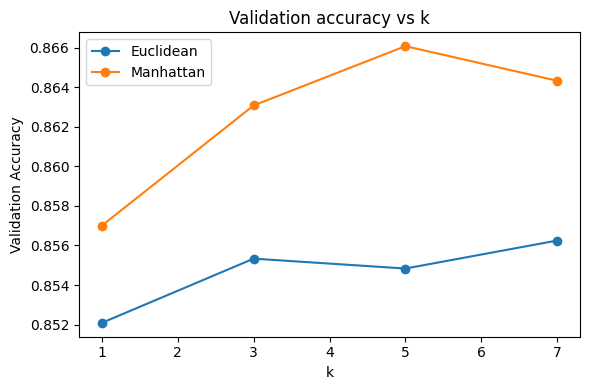

Best config -> metric=manhattan, k=5, val_acc=0.8661
Total tuning time: 257.36s


In [18]:
k_values = [1,3,5,7]
metrics = ["euclidean", "manhattan"]
val_results = []

tune_start = perf_counter()
for metric in metrics:
    for k in k_values:
        t0 = perf_counter()
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        knn.fit(X_train_std, y_train)
        t1 = perf_counter()
        y_val_pred = knn.predict(X_val_std)
        acc = accuracy_score(y_val, y_val_pred)
        t2 = perf_counter()
        val_results.append({
            "metric": metric, "k": k, "val_accuracy": acc,
            "fit_time_s": t1 - t0, "predict_time_s": t2 - t1
        })
tune_end = perf_counter()

val_df = pd.DataFrame(val_results).sort_values(["metric","k"]).reset_index(drop=True)
display(val_df)

# Plot validation accuracy vs k for each metric
fig, ax = plt.subplots(figsize=(6,4))
for metric in metrics:
    subset = val_df[val_df["metric"]==metric]
    ax.plot(subset["k"], subset["val_accuracy"], marker="o", label=metric.title())
ax.set_xlabel("k")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation accuracy vs k")
ax.legend()
plt.tight_layout()
plt.show()

best_row = val_df.iloc[val_df["val_accuracy"].idxmax()]
best_k = int(best_row["k"]); best_metric = str(best_row["metric"]); best_acc = float(best_row["val_accuracy"])
print(f"Best config -> metric={best_metric}, k={best_k}, val_acc={best_acc:.4f}")
print(f"Total tuning time: {tune_end - tune_start:.2f}s")

Test Accuracy: 0.8613
Macro Precision: 0.8625  Macro Recall: 0.8613  Macro F1: 0.8609
Train time: 0.03s  Predict time: 64.12s


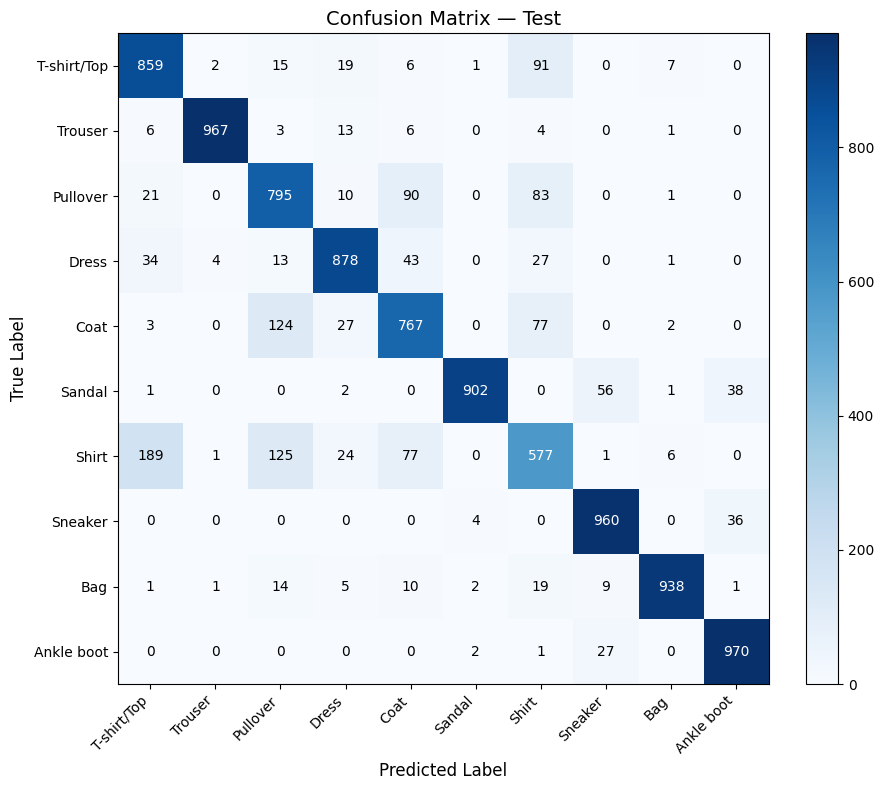

In [19]:
# Retrain with best hyperparameters on train+val
X_trval_std = np.vstack([X_train_std, X_val_std])
y_trval = np.concatenate([y_train, y_val])

train_start = perf_counter()
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, n_jobs=-1)
final_knn.fit(X_trval_std, y_trval)
train_end = perf_counter()

pred_start = perf_counter()
y_test_pred = final_knn.predict(X_test_std)
pred_end = perf_counter()

test_acc = accuracy_score(y_test, y_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {prec:.4f}  Macro Recall: {rec:.4f}  Macro F1: {f1:.4f}")
print(f"Train time: {train_end - train_start:.2f}s  Predict time: {pred_end - pred_start:.2f}s")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plot_confusion(cm, LABELS, title="Confusion Matrix — Test")

In [20]:
# Identify top-3 most confused class pairs (off-diagonal maxima)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for i, j in combinations(range(10), 2):
    mis_ij = cm_off[i, j] + cm_off[j, i]
    pairs.append(((i, j), mis_ij))
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:3]
pairs_sorted

[((0, 6), 280), ((2, 4), 214), ((2, 6), 208)]